## Лабораторная работа №4 (2й семестр)

**Экспоненциальное сглаживание**

----

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error

df = pd.read_csv('lab_03/data.csv', sep=';')
df.rename(columns={'date1': 'month', 'date2': 'year', 'x2': 'avg_daily_rate'}, inplace=True)
df.drop(columns=['x1', 'x3', 'x4'], inplace=True)
df['avg_daily_rate'] = df['avg_daily_rate'].apply(lambda x: '.'.join(x.split(',')))
df = df[df['avg_daily_rate'] != ' ']
df['avg_daily_rate'] = df['avg_daily_rate'].astype(float)
df['year'] = df['year'].astype(int)

def month2n(month: str):
    monthes = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
    ]

    return monthes.index(month)


df['month_n'] = df['month'].apply(month2n)
df['timestamp'] = (df['year'] - 1994) * 12 + df['month_n']
df.head()

,month,year,avg_daily_rate,month_n,timestamp
0,January,1994,104.04,0,0
1,February,1994,102.74,1,1
2,March,1994,105.23,2,2
3,April,1994,113.63,3,3
4,May,1994,120.77,4,4


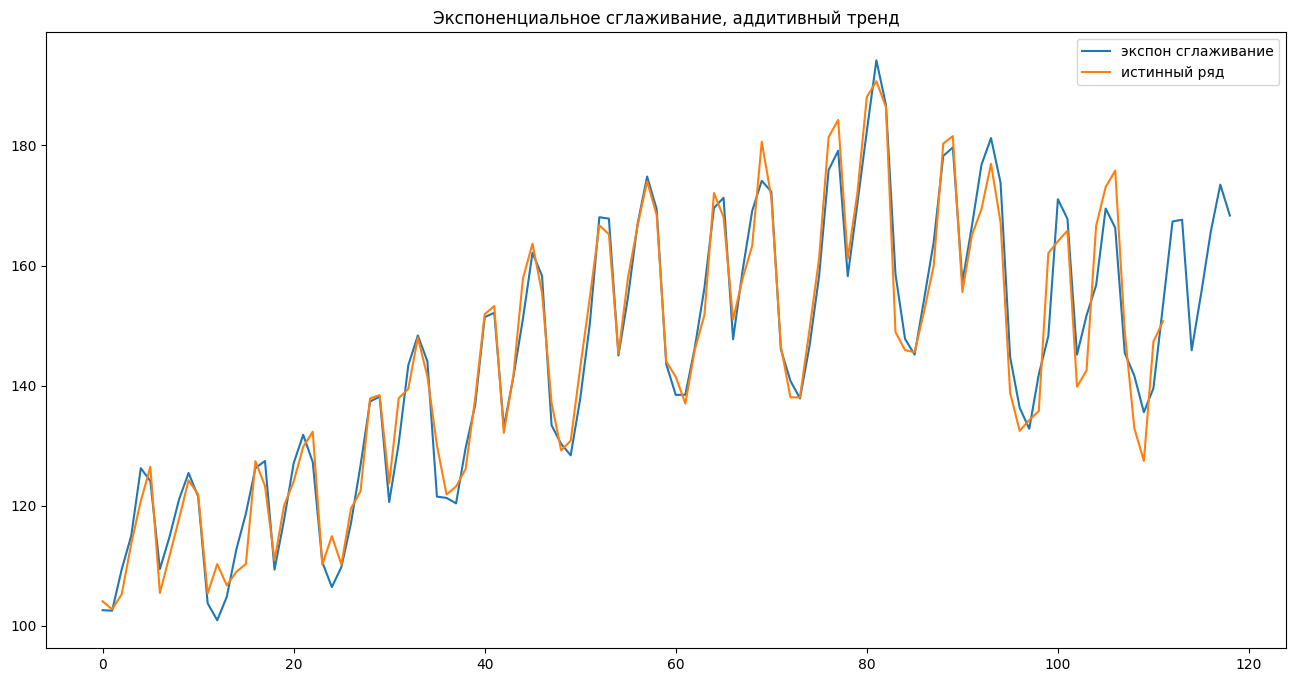

In [17]:
fit_ad = ExponentialSmoothing(
        np.asarray(df['avg_daily_rate']),
        seasonal_periods=12, trend='additive',
        seasonal='multiplicative',
        damped_trend = True).fit()
forecast_ad = fit_ad.predict(0, 118)

plt.figure(figsize=(16,8))
plt.plot(forecast_ad, label='экспон сглаживание')
plt.plot(np.asarray(df['avg_daily_rate']), label='истинный ряд')
plt.title("Экспоненциальное сглаживание, аддитивный тренд")
plt.legend(loc='best')
plt.show()

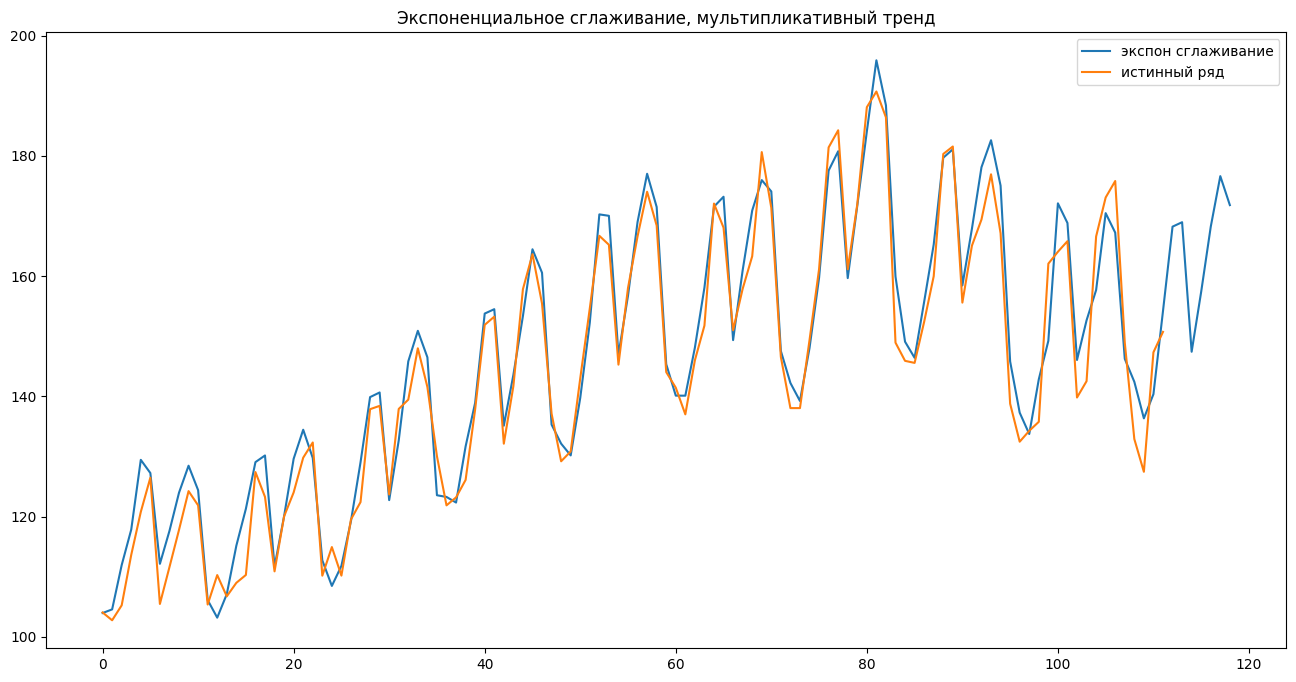

In [18]:
fit_prod = ExponentialSmoothing(np.asarray(df['avg_daily_rate']),
        seasonal_periods=12, 
        trend='multiplicative', 
        seasonal='multiplicative', 
        damped_trend = True).fit()
forecast_prod = fit_prod.predict(0, 118)

plt.figure(figsize=(16,8))
plt.plot(forecast_prod, label='экспон сглаживание')
plt.plot(np.asarray(df['avg_daily_rate']), label='истинный ряд')
plt.title("Экспоненциальное сглаживание, мультипликативный тренд")
plt.legend(loc='best')
plt.show()

#### Ряд с аддитивным трендом кажется лучше приближает истинный, проверим MAE

In [19]:
ad_trend_err = mean_absolute_error(np.asarray(df['avg_daily_rate']), forecast_ad[:112])
prod_trend_err = mean_absolute_error(np.asarray(df['avg_daily_rate']), forecast_prod[:112])

print(f"MAE аддитивный тренд: {ad_trend_err:.2f}")
print(f"MAE мультипликативный тренд: {prod_trend_err:.2f}")

MAE аддитивный тренд: 3.41
MAE мультипликативный тренд: 3.89


#### Ошибка у него тоже меньше